# Books to Scrape: Scraping & Exploratory Data Analysis
Scrapes all 50 catalogue pages from books.toscrape.com, cleans the data, and explores prices, ratings and availability.

## 1. Imports & setup

In [1]:
import time
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 2. Scrape the data

In [2]:
base_url = "https://books.toscrape.com/catalogue/page-{}.html"
rating_mapping = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}

books = []

for page_number in range(1, 51):
    url = base_url.format(page_number)
    response = requests.get(url)

    if response.status_code != 200:
        print(f"Could not access page {page_number}")
        continue

    soup = BeautifulSoup(response.text, "html.parser")
    book_items = soup.select("article.product_pod")

    for book in book_items:
        title = book.h3.a["title"]

        price_text = book.select_one(".price_color").text.strip()
        clean_price = price_text.replace("Â£", "").replace("£", "")
        price = float(clean_price)

        availability = book.select_one(".availability").text.strip()

        rating = book.select_one("p.star-rating")["class"][1]
        rating_number = rating_mapping.get(rating)

        relative_url = book.h3.a["href"]
        product_url = "https://books.toscrape.com/catalogue/" + relative_url

        books.append({
            "title": title,
            "price_gbp": price,
            "availability": availability,
            "rating": rating_number,
            "product_url": product_url,
        })

    time.sleep(0.2)

books_df = pd.DataFrame(books)

In [3]:
books_df.head()

,title,price_gbp,availability,rating,product_url
0,A Light in the Attic,51.77,In stock,3,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,53.74,In stock,1,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,50.10,In stock,1,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,47.82,In stock,4,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,54.23,In stock,5,https://books.toscrape.com/catalogue/sapiens-a...


In [4]:
print("Number of rows:", len(books_df))
print("Number of columns:", len(books_df.columns))
books_df.info()

Number of rows: 1000
Number of columns: 5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         1000 non-null   object 
 1   price_gbp     1000 non-null   float64
 2   availability  1000 non-null   object 
 3   rating        1000 non-null   int64  
 4   product_url   1000 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 39.2+ KB


In [5]:
books_df.head(10)

,title,price_gbp,availability,rating,product_url
0,A Light in the Attic,51.77,In stock,3,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,53.74,In stock,1,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,50.10,In stock,1,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,47.82,In stock,4,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,54.23,In stock,5,https://books.toscrape.com/catalogue/sapiens-a...
5,The Requiem Red,22.65,In stock,1,https://books.toscrape.com/catalogue/the-requi...
6,The Dirty Little Secrets of Getting Your Dream...,33.34,In stock,4,https://books.toscrape.com/catalogue/the-dirty...
7,The Coming Woman: A Novel Based on the Life of...,17.93,In stock,3,https://books.toscrape.com/catalogue/the-comin...
8,The Boys in the Boat: Nine Americans and Their...,22.60,In stock,4,https://books.toscrape.com/catalogue/the-boys-...
9,The Black Maria,52.15,In stock,1,https://books.toscrape.com/catalogue/the-black...


In [6]:
books_df.tail()

,title,price_gbp,availability,rating,product_url
995,Alice in Wonderland (Alice's Adventures in Won...,55.53,In stock,1,https://books.toscrape.com/catalogue/alice-in-...
996,"Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human #1)",57.06,In stock,4,https://books.toscrape.com/catalogue/ajin-demi...
997,A Spy's Devotion (The Regency Spies of London #1),16.97,In stock,5,https://books.toscrape.com/catalogue/a-spys-de...
998,1st to Die (Women's Murder Club #1),53.98,In stock,1,https://books.toscrape.com/catalogue/1st-to-di...
999,"1,000 Places to See Before You Die",26.08,In stock,5,https://books.toscrape.com/catalogue/1000-plac...


In [7]:
print(books_df.columns.tolist())

['title', 'price_gbp', 'availability', 'rating', 'product_url']


In [8]:
books_df.to_csv("books.csv", index=False)

## 3. Load & inspect the CSV

In [9]:
books_df = pd.read_csv("books.csv")

In [10]:
books_df.head()

,title,price_gbp,availability,rating,product_url
0,A Light in the Attic,51.77,In stock,3,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,53.74,In stock,1,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,50.10,In stock,1,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,47.82,In stock,4,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,54.23,In stock,5,https://books.toscrape.com/catalogue/sapiens-a...


In [11]:
books_df.shape

(1000, 5)

In [12]:
books_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         1000 non-null   object 
 1   price_gbp     1000 non-null   float64
 2   availability  1000 non-null   object 
 3   rating        1000 non-null   int64  
 4   product_url   1000 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 39.2+ KB


In [13]:
books_df.describe()

,price_gbp,rating
count,1000.00000,1000.000000
mean,35.07035,2.923000
std,14.44669,1.434967
min,10.00000,1.000000
25%,22.10750,2.000000
50%,35.98000,3.000000
75%,47.45750,4.000000
max,59.99000,5.000000


In [14]:
books_df.isnull().sum()

,0
title,0
price_gbp,0
availability,0
rating,0
product_url,0


In [15]:
books_df.duplicated().sum()

np.int64(0)

In [16]:
books_df["rating"].value_counts().sort_index()

,count
rating,
1,226
2,196
3,203
4,179
5,196


In [17]:
books_df["availability"].value_counts()

,count
availability,
In stock,1000


## 4. Clean the data

In [18]:
books_df = books_df.drop_duplicates()
books_df.isnull().sum()

,0
title,0
price_gbp,0
availability,0
rating,0
product_url,0


In [19]:
books_df["price_gbp"] = pd.to_numeric(books_df["price_gbp"], errors="coerce")
books_df = books_df.dropna(subset=["title", "price_gbp", "rating"])
clean_books = books_df.copy()

## 5. Price statistics

In [20]:
average_price = clean_books["price_gbp"].mean()
median_price = clean_books["price_gbp"].median()
minimum_price = clean_books["price_gbp"].min()
maximum_price = clean_books["price_gbp"].max()

print("Average price:", round(average_price, 2))
print("Median price:", round(median_price, 2))
print("Minimum price:", minimum_price)
print("Maximum price:", maximum_price)

Average price: 35.07
Median price: 35.98
Minimum price: 10.0
Maximum price: 59.99


In [21]:
clean_books["price_gbp"].describe()

,price_gbp
count,1000.00000
mean,35.07035
std,14.44669
min,10.00000
25%,22.10750
50%,35.98000
75%,47.45750
max,59.99000


## 6. Rating analysis

In [22]:
rating_counts = clean_books["rating"].value_counts().sort_index()
print(rating_counts)

rating
1    226
2    196
3    203
4    179
5    196
Name: count, dtype: int64


In [23]:
rating_percentages = (
    clean_books["rating"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)
print(rating_percentages)

rating
1    22.6
2    19.6
3    20.3
4    17.9
5    19.6
Name: proportion, dtype: float64


In [24]:
most_common_rating = clean_books["rating"].mode()[0]
print("Most common rating:", most_common_rating)

Most common rating: 1


In [25]:
price_by_rating = (
    clean_books
    .groupby("rating")["price_gbp"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)
price_by_rating

,count,mean,median,min,max
rating,,,,,
1,226,34.56,34.77,10.40,59.64
2,196,34.81,36.22,10.02,59.95
3,203,34.69,33.78,10.16,59.99
4,179,36.09,37.80,10.01,59.45
5,196,35.37,36.90,10.00,59.92


In [26]:
correlation = clean_books["rating"].corr(clean_books["price_gbp"])
print("Correlation between rating and price:", round(correlation, 3))

Correlation between rating and price: 0.028


## 7. Outlier detection (IQR method)

In [27]:
q1 = clean_books["price_gbp"].quantile(0.25)
q3 = clean_books["price_gbp"].quantile(0.75)
iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

Lower limit: -15.91749999999999
Upper limit: 85.48249999999999


In [28]:
outliers = clean_books[
    (clean_books["price_gbp"] < lower_limit) |
    (clean_books["price_gbp"] > upper_limit)
]
outliers[["title", "price_gbp", "rating"]]

,title,price_gbp,rating


## 8. Visualizations

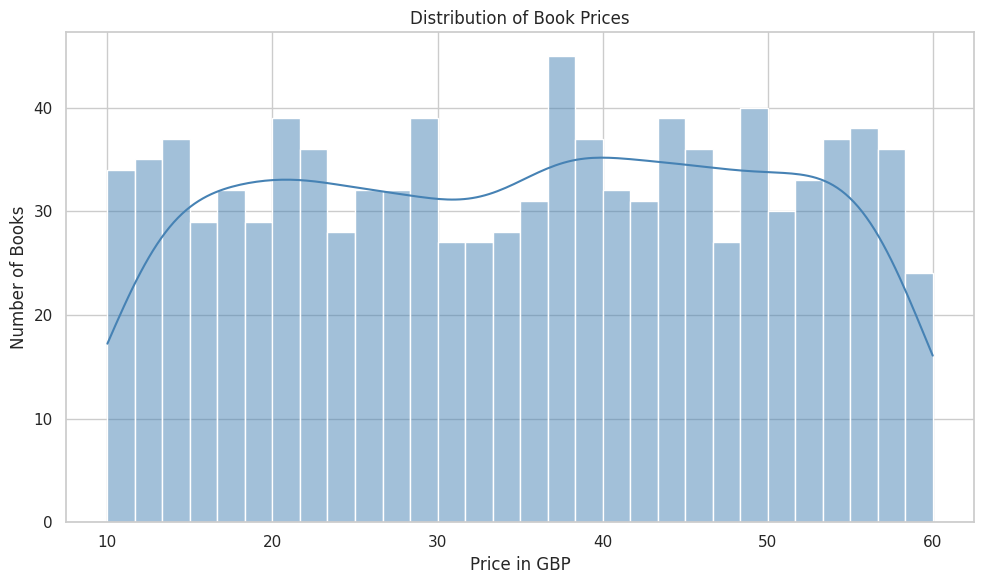

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(data=clean_books, x="price_gbp", bins=30, kde=True, color="steelblue")
plt.title("Distribution of Book Prices")
plt.xlabel("Price in GBP")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.show()

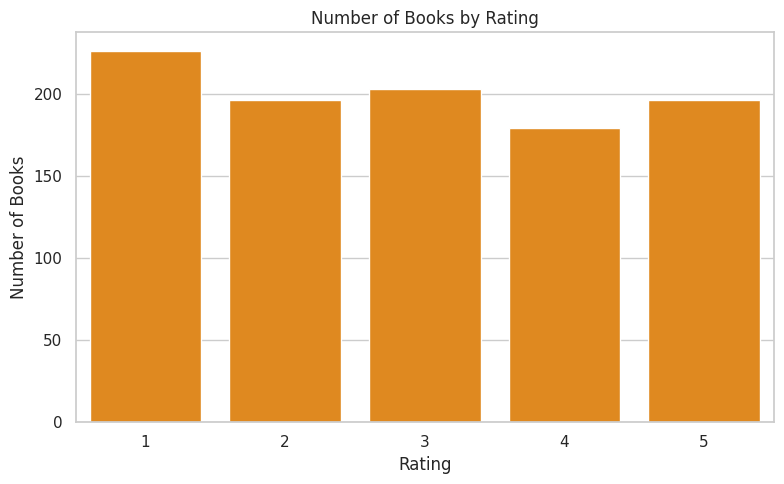

In [30]:
plt.figure(figsize=(8, 5))
sns.countplot(data=clean_books, x="rating", color="darkorange")
plt.title("Number of Books by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.show()

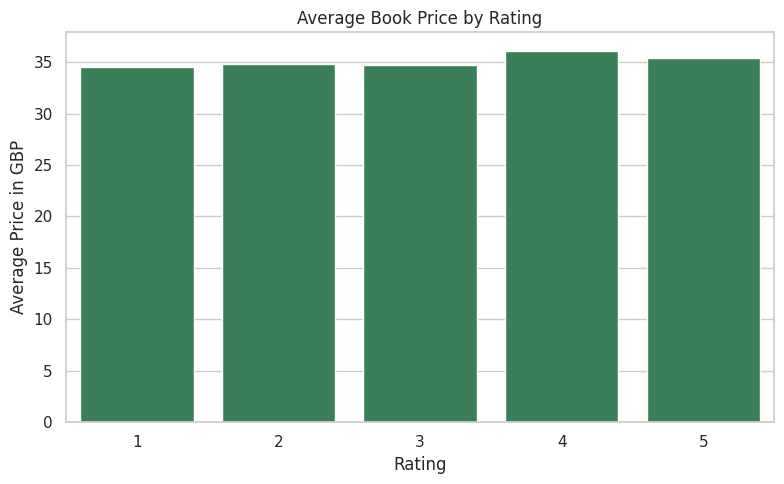

In [31]:
average_price_by_rating = (
    clean_books
    .groupby("rating")["price_gbp"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
sns.barplot(data=average_price_by_rating, x="rating", y="price_gbp", color="seagreen")
plt.title("Average Book Price by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Price in GBP")
plt.tight_layout()
plt.show()

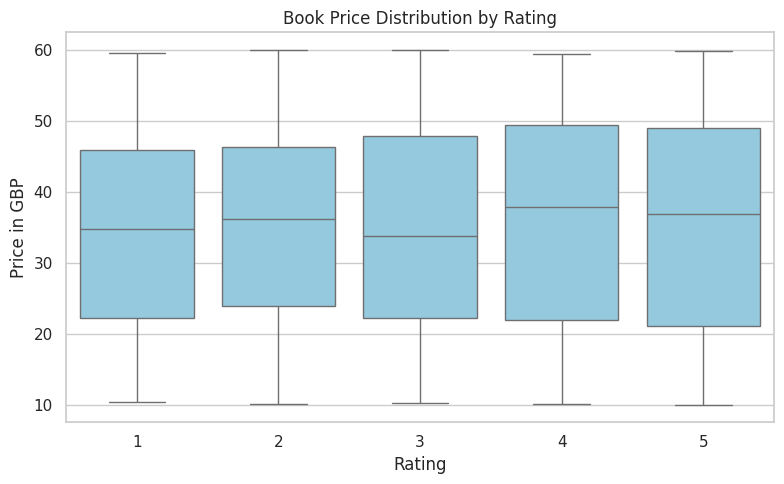

In [32]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=clean_books, x="rating", y="price_gbp", color="skyblue")
plt.title("Book Price Distribution by Rating")
plt.xlabel("Rating")
plt.ylabel("Price in GBP")
plt.tight_layout()
plt.show()

## 9. Availability analysis

In [33]:
clean_books["availability_count"] = (
    clean_books["availability"]
    .str.extract(r"(\d+)")
    .astype(float)
)
clean_books[["title", "availability", "availability_count"]].head()

,title,availability,availability_count
0,A Light in the Attic,In stock,NaN
1,Tipping the Velvet,In stock,NaN
2,Soumission,In stock,NaN
3,Sharp Objects,In stock,NaN
4,Sapiens: A Brief History of Humankind,In stock,NaN


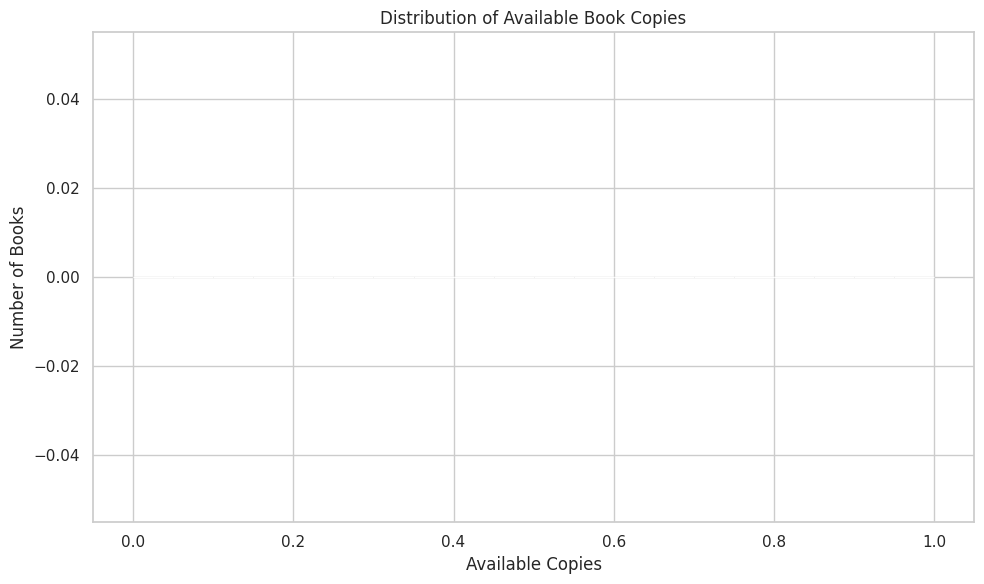

In [34]:
plt.figure(figsize=(10, 6))
sns.histplot(data=clean_books, x="availability_count", bins=20, color="purple")
plt.title("Distribution of Available Book Copies")
plt.xlabel("Available Copies")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.show()